In [1]:
import numpy as np
import matplotlib.pyplot as plt


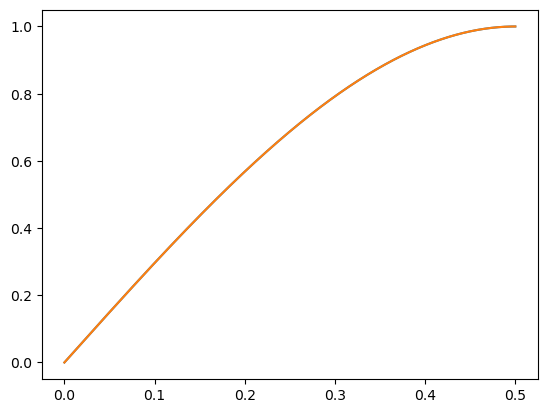

In [16]:
def deflection_poutre(L,npts=1000):
    xvals = np.linspace(0,L/2,npts)
    yvals = ((3/4)*L**2)*xvals - xvals**3
    yvalmax = np.max(yvals)
    return xvals,yvals, yvalmax

plt.figure()
L1=0.08
xvals1,yvals1, yvalmax1 = deflection_poutre(L1)
plt.plot(xvals1/L1, yvals1/yvalmax1)
L2 = 0.12
xvals2,yvals2, yvalmax2 = deflection_poutre(L2)
plt.plot(xvals2/L2, yvals2/yvalmax2)



[-4.01533200e-08 -4.90771098e-08 -5.95957605e-08 -7.19295824e-08
 -8.63209633e-08 -1.03035797e-07 -1.22364954e-07 -1.44625802e-07
 -1.70163767e-07 -1.99353940e-07 -2.32602730e-07 -2.70349561e-07
 -3.13068609e-07 -3.61270597e-07 -4.15504618e-07 -4.76360013e-07
 -5.44468294e-07 -6.20505108e-07 -7.05192245e-07 -7.99299695e-07
 -9.03647749e-07 -1.01910914e-06 -1.14661123e-06 -1.28713826e-06
 -1.44173360e-06 -1.61150210e-06 -1.79761244e-06 -2.00129957e-06
 -2.22386711e-06 -2.46668993e-06 -2.73121662e-06 -3.01897217e-06
 -3.33156050e-06 -3.67066724e-06 -4.03806239e-06 -4.43560313e-06
 -4.86523662e-06 -5.32900286e-06 -5.82903760e-06 -6.36757528e-06
 -6.94695203e-06 -7.56960874e-06 -8.23809409e-06 -8.95506772e-06
 -9.72330339e-06 -1.05456922e-05 -1.14252458e-05 -1.23650999e-05
 -1.33685173e-05 -1.44388915e-05]


C:\Users\Vasco Zanchi\AppData\Local\Temp\ipykernel_2208\2722192932.py:7: RuntimeWarning: invalid value encountered in sqrt
  x_sol = ( ((2/3)**(1/3) * gamma0) / ((np.sqrt(3)*np.sqrt(4*(gamma1**3)+27*(gamma0**2)) - 9*gamma0)**(1/3)))


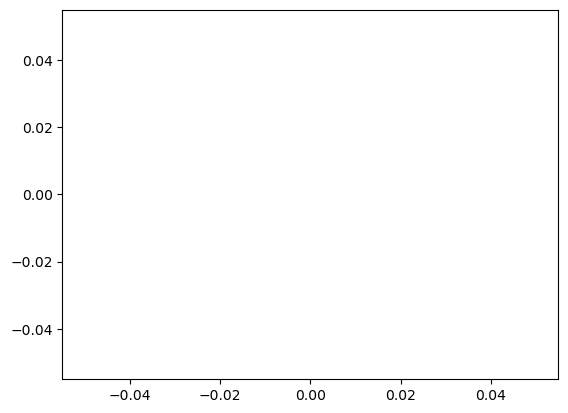

In [27]:
# solution de l'équation (w(x))/w_max = alpha (avec alpha constante typiquement =0.7 (transition entre zone courbée et non courbée))

def solution_longueur_coupure(L, alpha=0.7):
    gamma1 = -(3/4)*L**2
    gamma0 = (alpha*(L**3))/4
    print(4*(gamma1**3)+27*(gamma0**2))
    x_sol = ( ((2/3)**(1/3) * gamma0) / ((np.sqrt(3)*np.sqrt(4*(gamma1**3)+27*(gamma0**2)) - 9*gamma0)**(1/3)))
    return x_sol

plt.figure()
Lvals = np.linspace(0.06, 0.16)
plt.plot(Lvals, solution_longueur_coupure(Lvals))


Text(0, 0.5, 'x')

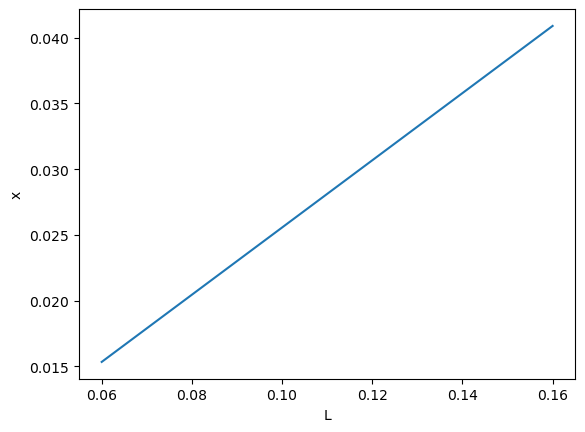

In [29]:
import numpy as np
import matplotlib.pyplot as plt

def solution_longueur_coupure(L, alpha=0.7):
    coeffs = [4, 0, -3, alpha]
    roots = np.roots(coeffs)
    
    u = np.real(roots[np.isreal(roots)])
    u = u[(u >= 0) & (u <= 0.5)]
    
    return float(u[0] * L)

Lvals = np.linspace(0.06, 0.16)

xvals = [solution_longueur_coupure(L) for L in Lvals]

plt.figure()
plt.plot(Lvals, xvals)
plt.xlabel('L')
plt.ylabel('x')